In [1]:
import os
import re
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def normalize_legal_name(name):
    """
    Creates a 'fingerprint' for comparison by removing legal noise.
    """
    if not name: return ""
    n = name.lower()
    # Remove m/s, versus, v., and common suffixes
    n = re.sub(r'\bm/s\.?\b|\bversus\b|\bv\.?s?\.?\b', ' ', n)
    n = re.sub(r'\band\s+(?:ors?|anr\.?)\b', ' ', n)
    # Return only alphanumeric for a 'fuzzy' match
    return re.sub(r'[^a-z0-9]', '', n)

In [3]:
def extract_precedents(text):
    """
    Captures [Party A] v. [Party B] while avoiding long sentences.
    """
    # Restrict the number of characters allowed around 'v.' to prevent paragraph capture
    pattern = r"([A-Z][\w\s\.&]{2,40} v\. [A-Z][\w\s\.&]{2,40})"
    found = re.findall(pattern, text)
    
    cleaned = []
    # These anchors help us cut off sentences that bleed into the citation
    noise_anchors = [
        r' held', r' observed', r' affirmed', r' clarified', r' relied', 
        r' mentioned', r' indicates', r' adopted', r' considered', 
        r' according', r' with reference', r' stands settled', r' accrues',
        r' should apply', r' survivorship', r' partition', r' the '
    ]
    noise_regex = r' (?:' + '|'.join(noise_anchors) + ')'

    for p in found:
        p_clean = p.replace('\n', ' ').strip()
        # Cut off at the first noise anchor
        p_clean = re.split(noise_regex, p_clean, flags=re.IGNORECASE)[0]
        
        # Final validation to ensure we have a valid v. pair
        if ' v. ' in p_clean and len(p_clean) < 100:
            cleaned.append(p_clean.strip())
            
    return list(set(cleaned))

In [4]:
def strict_fingerprint(name):
    """
    Normalizes case names to a bare-bones alphanumeric string.
    Crucial for matching 'versus' in metadata with 'v.' in text.
    """
    if not name: return ""
    n = name.lower()
    # Remove all variations of versus
    n = re.sub(r'\bm/s\.?\b|\bversus\b|\bv\.?s?\.?\b', '', n)
    # Remove common legal suffixes
    n = re.sub(r'\b(?:and|&)\s+(?:ors?|anr\.?|lrs\.?)\b', '', n)
    # Remove "In the case of", "In ", "Court in " prefixes
    n = re.sub(r'^in (?:the case of )?|^court in ', '', n)
    # Strip everything except alphanumeric
    return re.sub(r'[^a-z0-9]', '', n)

In [5]:
def extract_from_html(html_content):
    """
    Parses professional metadata from SCR HTML.
    """
    data = {
        "case_name": None,
        "coram": None, 
        "decision_date": None, 
        "case_no": None, 
        "disposal_nature": None
    }
    
    
    if not html_content: 
        return data
    
    patterns = {
        "case_name": r"<strong>(.*?)</strong>",
        "coram": r"Coram : (.*?)<br>",
        "decision_date": r"Decision Date :</span><font color='green'> (.*?)</font>",
        "case_no": r"Case No :</span><font color='green'> (.*?)</font>",
        "disposal_nature": r"Disposal Nature :</span><font color='green'> (.*?)</font>"
    }
    
    for key, pattern in patterns.items():
        match = re.search(pattern, html_content)
        if match:
            # Strips residual HTML like <strong> or <sup>
            clean_val = re.sub(r'<.*?>', '', match.group(1)).strip()
            data[key] = clean_val
    return data

In [6]:
def extract_legal_entities(text):
    """
    Extracts Acts, Articles, and IPC sections, cleaning newlines and duplicates.
    """
    # 1. Capture the entities using regex
    acts = re.findall(r'([A-Z][A-Za-z\s\&]+\s+Act[, ]\s*\d{4})', str(text))
    articles = re.findall(r'\bArticle\s+\d+[A-Z]?\b', str(text))
    ipc_sections = re.findall(r'\bSection\s+\d+\s+of\s+the\s+IPC\b|\bIPC\s+Section\s+\d+\b', str(text))
    
    combined = acts + articles + ipc_sections
    
    # 2. Clean up newlines and extra spaces
    cleaned_entities = []
    for entity in combined:
        # Replace newlines with space and collapse multiple spaces into one
        clean_name = re.sub(r'\s+', ' ', entity).strip()
        if len(clean_name) > 5:
            cleaned_entities.append(clean_name)
    
    # 3. Return a unique list
    return list(set(cleaned_entities))

In [ ]:
def build_final_parquet(text_folder, metadata_root, output_path):
    all_records = []
    # Collect all cleaned text files from the centralized directory 
    text_files = [f for f in os.listdir(text_folder) if f.endswith('.txt')]

    for filename in tqdm(text_files, desc="Building Dataset"):
        # Load the Full Text for the Kaggle corpus 
        with open(os.path.join(text_folder, filename), 'r', encoding='utf-8') as f:
            content = f.read()

        # Derive IDs and Dynamic Paths 
        # Strips '_EN' to match metadata JSON naming convention 
        base_id = filename.replace('_EN.txt', '').replace('.txt', '')
        
        parts = base_id.split('_')
        if parts[0] == 'S' and len(parts) > 1:
            year = parts[1]  # The year is in the second position
        else:
            year = parts[0]  # The year is in the first position
        
        
        
        json_path = os.path.join(metadata_root, year, "metadata", f"{base_id}.json")

        # Initialize Metadata Placeholders 
        meta_data = {
            "case_name": None, "coram": None, "decision_date": None, 
            "case_no": None, "disposal_nature": None, "neutral_citation": None
        }

        # Load Metadata First (Required for self-citation filtering) 
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r', encoding='utf-8') as jf:
                    meta_json = json.load(jf)
                    # Parses fields like Coram and Disposal Nature from HTML [cite: 3, 4, 5, 6]
                    meta_data.update(extract_from_html(meta_json.get("raw_html", "")))
                    meta_data["neutral_citation"] = meta_json.get("nc_display")
            except Exception as e:
                print(f"Warning: JSON error for {base_id}: {e}")

        # Extract and Filter Precedents 
        # Uses strict_fingerprint to handle 'versus' vs 'v.' discrepancies 
        current_name_fp = strict_fingerprint(meta_data["case_name"])
        raw_precedents = extract_precedents(content)
        filtered_precedents = []

        for p in raw_precedents:
            p_fp = strict_fingerprint(p)
            if not p_fp: 
                continue
            
            # SELF-CITATION FILTER: Skips if precedent matches current case fingerprint 
            if current_name_fp and (current_name_fp in p_fp or p_fp in current_name_fp):
                continue
                
            filtered_precedents.append(p)

        # Final Record Construction 
        record = {
            "file_id": base_id,
            "year": year,
            "case_name": meta_data["case_name"],
            "full_text": content,
            "acts": extract_legal_entities(content),
            "precedents": filtered_precedents,
            "coram": meta_data["coram"],
            "decision_date": meta_data["decision_date"],
            "case_no": meta_data["case_no"],
            "disposal_nature": meta_data["disposal_nature"],
            "neutral_citation": meta_data["neutral_citation"]
        }
        all_records.append(record)

    # 7. Save as Parquet with Snappy compression for Kaggle performance 
    df = pd.DataFrame(all_records)
    df.to_parquet(output_path, engine='pyarrow', index=False, compression='snappy')
    print(f"\nSuccessfully saved {len(df)} cases to {output_path}")

In [8]:
start_year = str(input("Enter start year: "))
end_year = str(input("Enter end year: "))

if __name__ == "__main__":
    TEXT_DIR = f"../../My_Datasets/Text_Datasets/texts_{start_year}-{end_year}"
    META_ROOT = f"../../My_Datasets/SC_{start_year}-{end_year}"
    OUTPUT = f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet"

    build_final_parquet(TEXT_DIR, META_ROOT, OUTPUT)

Building Dataset: 100%|██████████| 14209/14209 [02:03<00:00, 115.01it/s]



Successfully saved 14209 cases to ../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_1990-2009.parquet


In [9]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet(f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet")

# View the first 5 rows
print(df.head())

            file_id  year                                          case_name  \
0  1990_1_1027_1030  1990  COLLECTOR OF CENTRAL EXCISE, CALCUTTA versus B...   
1  1990_1_1031_1040  1990  COMMISSIONER OF SALES TAX, U.P. LUCKNOW versus...   
2    1990_1_115_133  1990  STATE OF MAHARASHTRA versus CHANDRAPRAKASH KEW...   
3    1990_1_134_143  1990    P.V.G. RAJU GARU versus STATE OF ANDHRA PRADESH   
4      1990_1_13_19  1990  WORKMEN OF ENGLISH ELECTRIC COMPANY OF INDIA L...   

                                           full_text  \
0  COLLECTOR OF CENTRAL EXCISE, CALCUTTA\nv.\nBER...   
1  COMMISSIONER OF SALES TAX, U.P. LUCKNOW\nv.\nA...   
2  STAIB OF MAHARASHTRA\nv.\nCHANDRAPRAKASH KEWAL...   
3  c\nP.V.G. RAJU GARU\nv.\nSTATE OF ANDHRA PRADE...   
4  WORKMEN OF ENGLISH ELECTRIC COMPANY OF INDIA A...   

                                                acts  \
0                 [Central Excises & Salt Act, 1944]   
1                                                 []   
2             

In [10]:
numcase = 50

In [11]:
print(df.iloc[numcase].T)

file_id                                                1990_1_561_575
year                                                             1990
case_name           S. PRAKASHA RAO AND ANR. versus COMMISSIONER O...
full_text           ~\nS. PRAKASHA RAO AND ANR.\nv.\nCOMMISSIONER ...
acts                [Article 136, Bombay Land Requisition Act, 194...
precedents          [Kochuni v. States of Madras & Kera, S.P. RAO ...
coram                    RANGANATH MISRA*, M.M. PUNCHHI, K. RAMASWAMY
decision_date                                              23-02-1990
case_no                                    CIVIL APPEAL No. 1259/1990
disposal_nature                                             Dismissed
neutral_citation                                           1990INSC55
Name: 50, dtype: object


In [12]:
filename = df.loc[numcase, "file_id"]
print(filename)

caseName = df.loc[numcase, 'case_name']
print(caseName)

1990_1_561_575
S. PRAKASHA RAO AND ANR. versus COMMISSIONER OF COMMERCIAL TAXES AND ORS.


In [13]:
value = df.loc[numcase, 'precedents']
print(value)

['Kochuni v. States of Madras & Kera'
 'S.P. RAO v. COMMR. OF COMMERCIAL TAXES'
 'Lilavati Bai v. The State of Bombay'
 'S.P.RAO v. COMMR.OFCOMMERCIAL TAXES']


In [14]:
acts = df.loc[numcase, 'acts']
print(acts)

['Article 136' 'Bombay Land Requisition Act, 1948'
 'D brought into the Constitution by Thirtysecond Amendment Act, 1973'
 'Article 371']



--- Missing Values (Top 15) ---
disposal_nature     5.83
coram               2.68
case_name           2.65
neutral_citation    2.65
case_no             2.65
decision_date       2.65
file_id             0.00
year                0.00
precedents          0.00
full_text           0.00
acts                0.00
dtype: float64


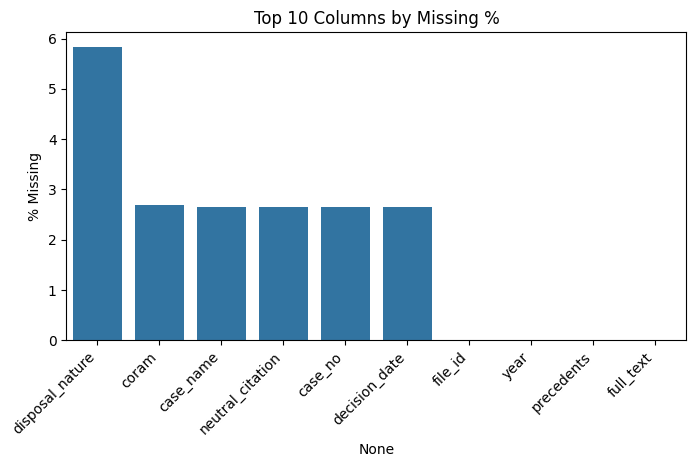

In [15]:
# Missing value audit
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Top 10 Acts/Articles Distribution ---
acts
Article 226                      1402
Article 136                      1080
Article 14                       1073
Article 32                        998
Land Acquisition Act, 1894        551
Evidence Act, 1872                529
Income Tax Act, 1961              449
Industrial Disputes Act, 1947     401
Article 21                        389
Article 309                       373
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6836\252362746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')


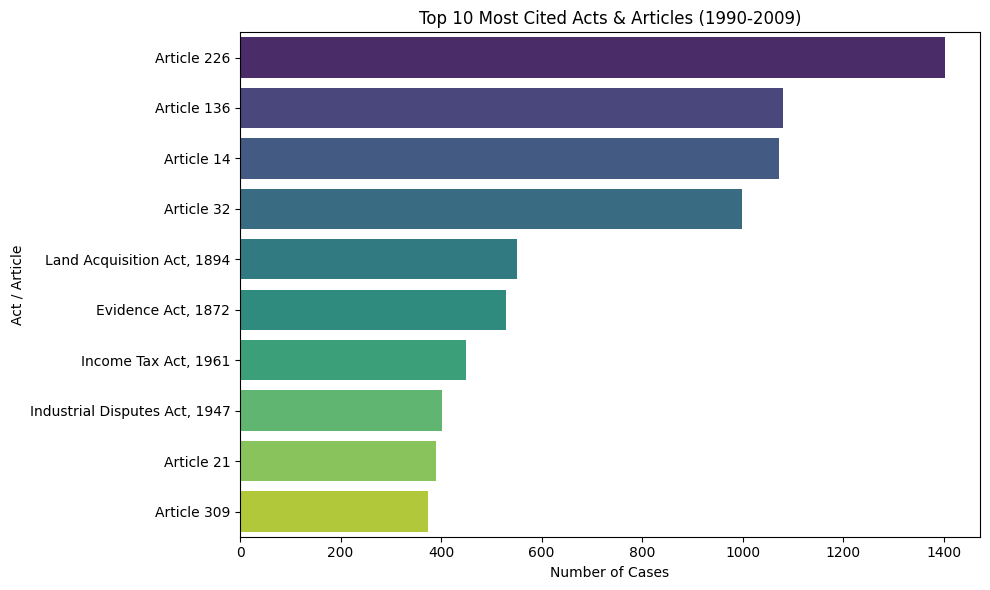

In [16]:
# 1. Explode the 'acts' column so each Act gets its own row
df_exploded = df.explode('acts')

#  Drop rows where 'acts' might be None (cases with no identified laws)
df_exploded = df_exploded.dropna(subset=['acts'])

# calculate the Top 10 Acts for a readable plot
top_10_acts = df_exploded['acts'].value_counts().nlargest(10)

print("\n--- Top 10 Acts/Articles Distribution ---")
print(top_10_acts)

# 4. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')

plt.title(f"Top 10 Most Cited Acts & Articles ({start_year}-{end_year})")
plt.xlabel("Number of Cases")
plt.ylabel("Act / Article")
plt.tight_layout()
plt.show()

In [ ]:
# Identify cases where metadata extraction failed
failed_cases = df[df['case_name'].isnull()][['file_id', 'year']].head(10)

print("--- Samples of Files with Missing Metadata ---")
print(failed_cases)

--- Samples of Files with Missing Metadata ---
              file_id  year
6276    2008_10_48_51  2008
6278     2008_10_4_47  2008
6279    2008_10_52_61  2008
6288    2008_10_62_70  2008
6316  2008_10_905_915  2008
6340  2008_11_145_160  2008
6342  2008_11_172_183  2008
6343  2008_11_184_210  2008
6346  2008_11_211_242  2008
6347  2008_11_243_269  2008
